In [12]:
# ==========================================
# CELL 1: SETUP AND EXPLICIT PREPROCESSING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Invistico_Airline.csv')

# 2. Explicitly handle missing values as requested by the evaluator
median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)

# 3. Explicit Target Encoding for 'satisfaction'
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# 4. Separate Features (X) and Target (y)
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

# 5. Extract column types for encoding (handles 'Class', 'Type of Travel', etc.)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 6. Build the ColumnTransformer Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# 7. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data successfully preprocessed and split!")


Data successfully preprocessed and split!


In [13]:
# ==========================================
# CELL 2: HYPERPARAMETER TUNING
# ==========================================
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Define parameter grid to prevent overfitting
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, 15],
    'classifier__min_samples_split': [10, 20, 50],
    'classifier__min_samples_leaf': [5, 10, 20]
}

print("Running GridSearchCV for Decision Tree...")
grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Running GridSearchCV for Decision Tree...
Best Hyperparameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}


Decision Tree Test F1-Score: 0.9441

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     11759
           1       0.96      0.93      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



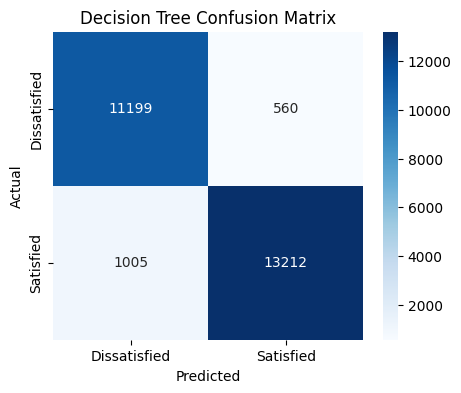

In [14]:
# ==========================================
# CELL 3: PERFORMANCE EVALUATION
# ==========================================
y_pred_dt = best_dt_model.predict(X_test)

print(f"Decision Tree Test F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Generate and plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

/tmp/ipykernel_3569/1978662607.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


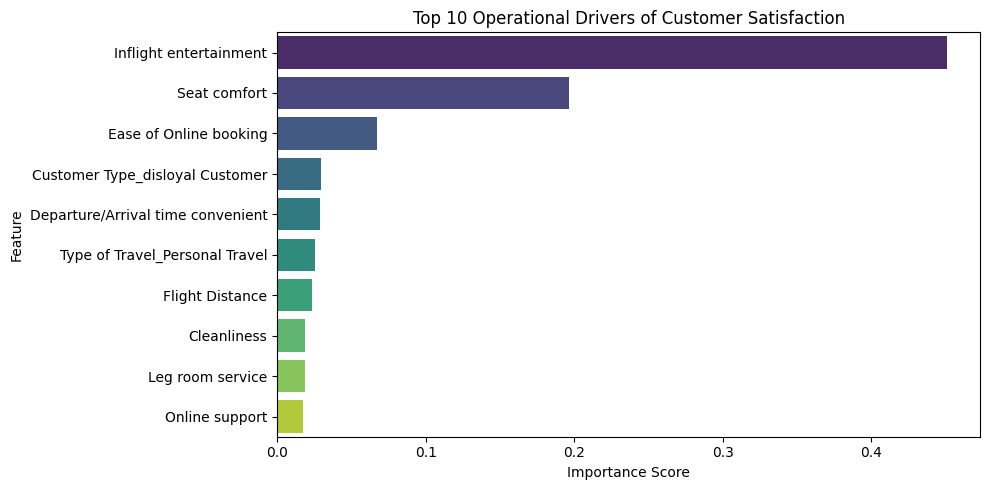

In [15]:
# ==========================================
# CELL 4: FEATURE IMPORTANCE EXTRACTION
# ==========================================
# Extract feature names after encoding transformations
encoded_cat_features = best_dt_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + encoded_cat_features

# Get feature importance scores
importances = best_dt_model.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot top 10 operational drivers
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Operational Drivers of Customer Satisfaction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

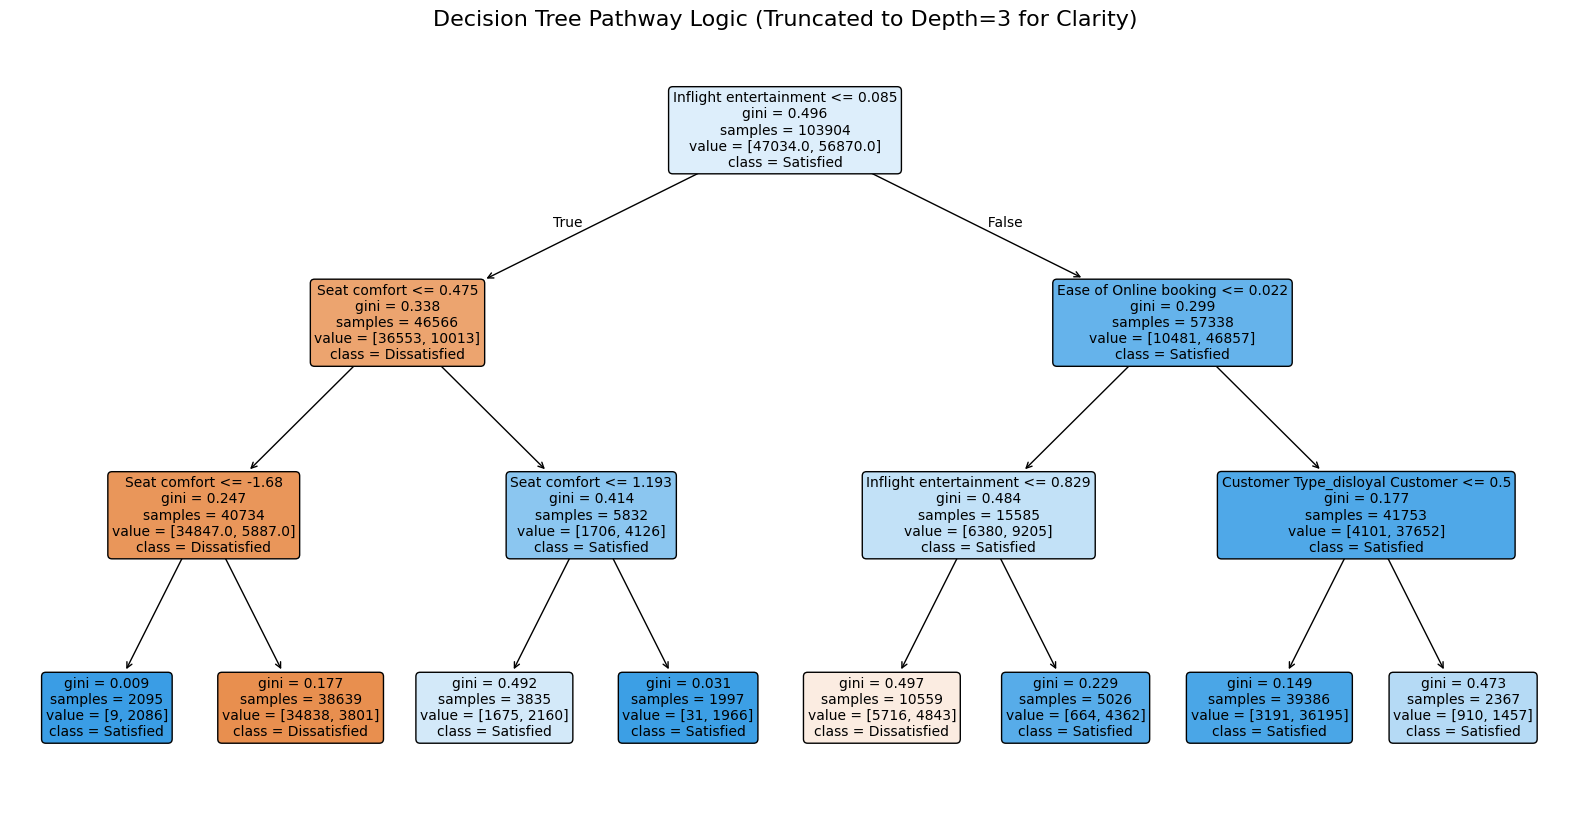

In [16]:
# ==========================================
# CELL 5: DECISION PATHWAY VISUALIZATION
# ==========================================
plt.figure(figsize=(20, 10))
visual_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
visual_tree.fit(best_dt_model.named_steps['preprocessor'].transform(X_train), y_train)

plot_tree(visual_tree, feature_names=all_features,
          class_names=['Dissatisfied', 'Satisfied'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Pathway Logic (Truncated to Depth=3 for Clarity)", fontsize=16)
plt.show()

In [17]:
# ==========================================
# CELL 6: LOGISTIC REGRESSION COMPARISON
# ==========================================
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print(f"Logistic Regression Test F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test F1-Score: 0.8437

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976

